# Practice 1: PyTorch FashionMNIST Classification

## MLP vs CNN — Comparison

| Step | Description | What it does | Import path |
|------|-------------|--------------|-------------|
| 1 | Import Libraries | Load PyTorch, src modules, detect device | — |
| 2 | Load Dataset | Download FashionMNIST + apply transforms | `src/data_utils.py` |
| 3 | Explore Dataset | Shape, class distribution, pixel stats | `src/vis_utils.py` |
| 4 | Create DataLoaders | Split into train/test batches | `src/data_utils.py` |
| 5 | Define Models | MLP (Linear) vs CNN (Conv2d) | — |
| 6 | Train Both Models | 10 epochs, log loss per epoch | `src/train_utils.py` |
| 7 | Compare: Loss Curves | Loss curves of MLP + CNN overlaid | `src/vis_utils.py` |
| 8 | Compare: Confusion Matrices | Per-class TPR/FPR/Precision + heatmaps | `src/eval_utils.py` |
| 9 | Compare: ROC Curves | Per-class ROC curves + AUC scores | `src/eval_utils.py` + `src/vis_utils.py` |
| 10 | Compare: PR Curves | Per-class Precision-Recall curves + AP | `src/eval_utils.py` + `src/vis_utils.py` |
| 11 | Summary Table | Accuracy / ROC-AUC / PR-AUC / Params side-by-side | `src/eval_utils.py` |
| 12 | Save Models | Save .pth weights to `outputs/model/` | `src/model_utils.py` |
| 13 | Display Predictions | Predicted vs actual images for MLP + CNN | `src/vis_utils.py` |

---

## 1. Import Libraries

Import `src/` utility modules, PyTorch core, and auto-detect device (MPS > CUDA > CPU).

In [7]:
import sys
sys.path.append('..')

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

from src.data_utils import get_fashionmnist_transforms, load_fashionmnist, get_dataloaders
from src.data_validation import analyze_dataset, compute_pixel_statistics, check_class_distribution, visualize_random_samples, detect_outliers
from src.preprocessing import compute_dataset_statistics, normalize_dataset, build_advanced_transforms, get_class_weights
from src.vis_utils import explore_dataset, plot_losses, plot_confusion_matrix
from src.vis_utils import plot_roc_curves, plot_pr_curves, plot_predictions
from src.model_utils import save_model
from src.train_utils import train_model
from src.eval_utils import evaluate_detailed, get_all_probas_and_labels
from src.eval_utils import compute_roc_auc_scores, compute_pr_auc_scores, print_comparison_table

print(f"PyTorch version: {torch.__version__}")
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(f"Using device: {device}")

PyTorch version: 2.13.0
Using device: mps


## 2. Load Dataset

Download FashionMNIST (60k train / 10k test) and normalize pixels to [-1, 1] with `ToTensor()` + `Normalize(0.5, 0.5)`.

In [8]:
transform = get_fashionmnist_transforms(
    normalize=True,
    resize=None,
    augmentation=False
)
train_dataset, val_dataset, test_dataset = load_fashionmnist(
    transform=transform,
    root="../data",
    val_split=0.1
)

## 3. Explore Dataset

Print basic info (classes, shape), show 10 sample images, class distribution bar chart, and pixel intensity histogram.

Number of classes: 10
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
Num samples: 54000
Image shape: torch.Size([1, 28, 28])


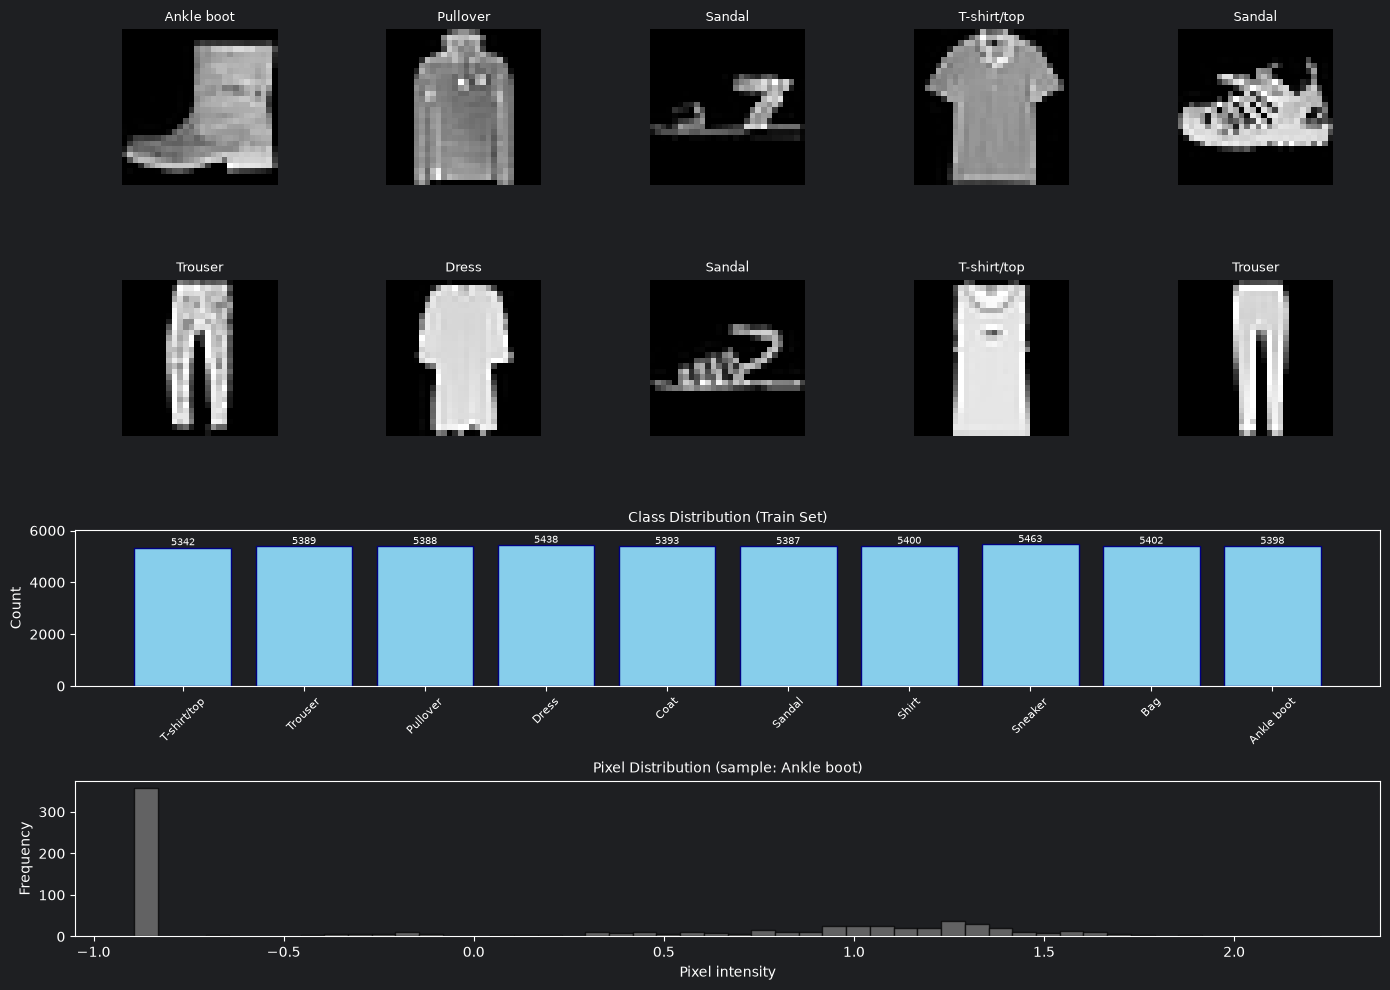

Image tensor shape: torch.Size([1, 28, 28])
Image tensor dtype: torch.float32
Pixel value range: [-0.8924, 2.2278]
Mean pixel value: 0.0882
Std pixel value: 0.9935


In [9]:
class_names = train_dataset.dataset.classes
explore_dataset(train_dataset, class_names)

## 4. Create DataLoaders

Batch size = 64. Train loader shuffles, test loader does not.

In [10]:
train_loader, val_loader, test_loader = get_dataloaders(
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    test_dataset=test_dataset,
    batch_size=64,
    num_workers=0,
    pin_memory=False,
    class_balanced=False
)
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Training batches: 844
Validation batches: 94
Test batches: 157


## 5. Define Models

**MLP:** `784 -> 256 -> 128 -> 10`, ReLU, Dropout(0.2).

**CNN:** `Conv2D(1->32) -> Pool -> Conv2D(32->64) -> Pool -> FC 128 -> 10`, ReLU, Dropout(0.25).

In [11]:
class MLP(nn.Module):
    def __init__(self, input_size=784, hidden_1=256, hidden_2=128, num_classes=10, dropout=0.2):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(input_size, hidden_1)
        self.fc2 = nn.Linear(hidden_1, hidden_2)
        self.fc3 = nn.Linear(hidden_2, num_classes)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x


class CNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, num_classes)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x


model_mlp = MLP().to(device)
model_cnn = CNN().to(device)

mlp_params = sum(p.numel() for p in model_mlp.parameters())
cnn_params = sum(p.numel() for p in model_cnn.parameters())
print(f'MLP params: {mlp_params:,}')
print(f'CNN params: {cnn_params:,}')

MLP params: 235,146
CNN params: 421,642


## 6. Train Both Models

Both use `CrossEntropyLoss`, `Adam(lr=0.001)`, 10 epochs. `train_model` handles forward / backward / optimize loop.

In [12]:
criterion = nn.CrossEntropyLoss()
num_epochs = 10

print('--- Training MLP ---')
optimizer_mlp = optim.Adam(model_mlp.parameters(), lr=0.001)
train_losses_mlp = train_model(model_mlp, train_loader, criterion, optimizer_mlp, device, num_epochs)

print('\n--- Training CNN ---')
optimizer_cnn = optim.Adam(model_cnn.parameters(), lr=0.001)
train_losses_cnn = train_model(model_cnn, train_loader, criterion, optimizer_cnn, device, num_epochs)

--- Training MLP ---
Epoch [1/10], Loss: 0.5146
Epoch [2/10], Loss: 0.3908
Epoch [3/10], Loss: 0.3543
Epoch [4/10], Loss: 0.3341
Epoch [5/10], Loss: 0.3153
Epoch [6/10], Loss: 0.3061
Epoch [7/10], Loss: 0.2970
Epoch [8/10], Loss: 0.2853
Epoch [9/10], Loss: 0.2798
Epoch [10/10], Loss: 0.2697

--- Training CNN ---
Epoch [1/10], Loss: 0.4505
Epoch [2/10], Loss: 0.2881
Epoch [3/10], Loss: 0.2411
Epoch [4/10], Loss: 0.2130
Epoch [5/10], Loss: 0.1867
Epoch [6/10], Loss: 0.1659
Epoch [7/10], Loss: 0.1478
Epoch [8/10], Loss: 0.1325
Epoch [9/10], Loss: 0.1174
Epoch [10/10], Loss: 0.1052


## 7. Compare: Loss Curves

MLP (blue) vs CNN (orange) loss per epoch — CNN converges faster and reaches lower loss.

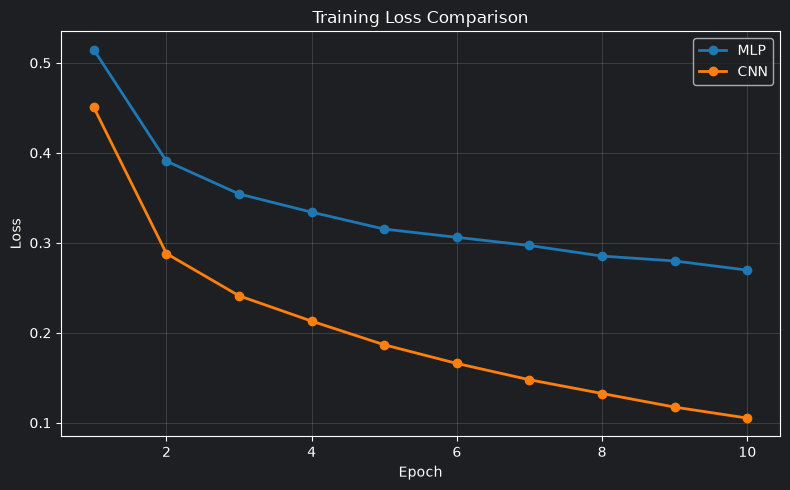

In [13]:
plot_losses({'MLP': train_losses_mlp['train_losses'], 'CNN': train_losses_cnn['train_losses']})

## 8. Compare: Confusion Matrices

Print accuracy, TPR (Recall), FPR, Precision per class + confusion matrix heatmaps for both models.

  Test Accuracy: 87.42%
  Class           TPR(Recall)        FPR  Precision
  ---------------------------------------------
  T-shirt/top         0.7690     0.0127     0.8709
  Trouser             0.9680     0.0016     0.9857
  Pullover            0.7390     0.0176     0.8239
  Dress               0.9220     0.0188     0.8451
  Coat                0.7890     0.0222     0.7978
  Sandal              0.9600     0.0053     0.9524
  Shirt               0.7360     0.0478     0.6312
  Sneaker             0.9370     0.0068     0.9389
  Bag                 0.9670     0.0026     0.9768
  Ankle boot          0.9550     0.0046     0.9588


  Test Accuracy: 91.74%
  Class           TPR(Recall)        FPR  Precision
  ---------------------------------------------
  T-shirt/top         0.8360     0.0124     0.8819
  Trouser             0.9840     0.0008     0.9929
  Pullover            0.8700     0.0127     0.8841
  Dress               0.9000     0.0082     0.9240
  Coat                0.8730     0.0

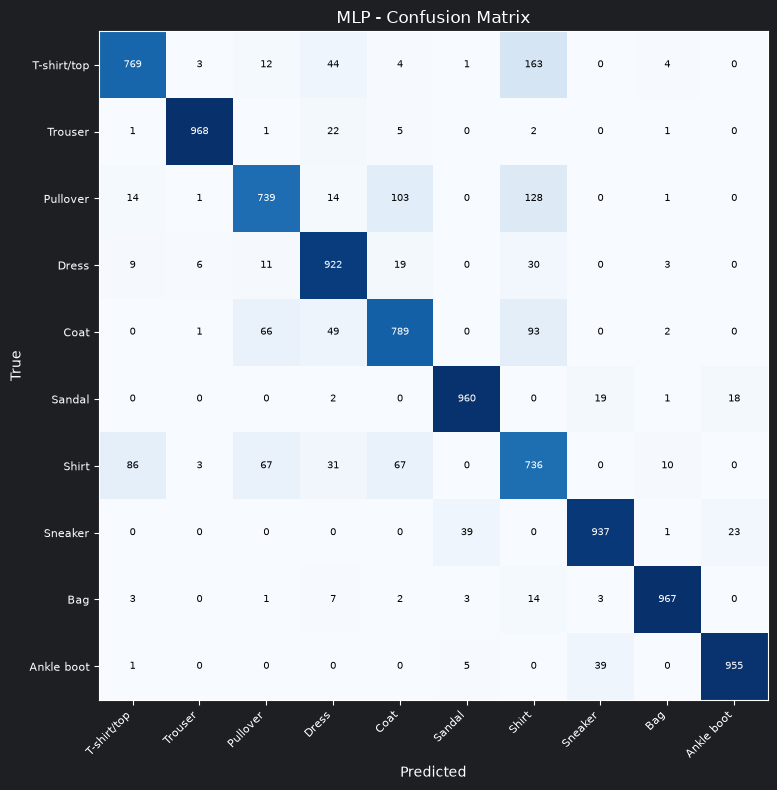

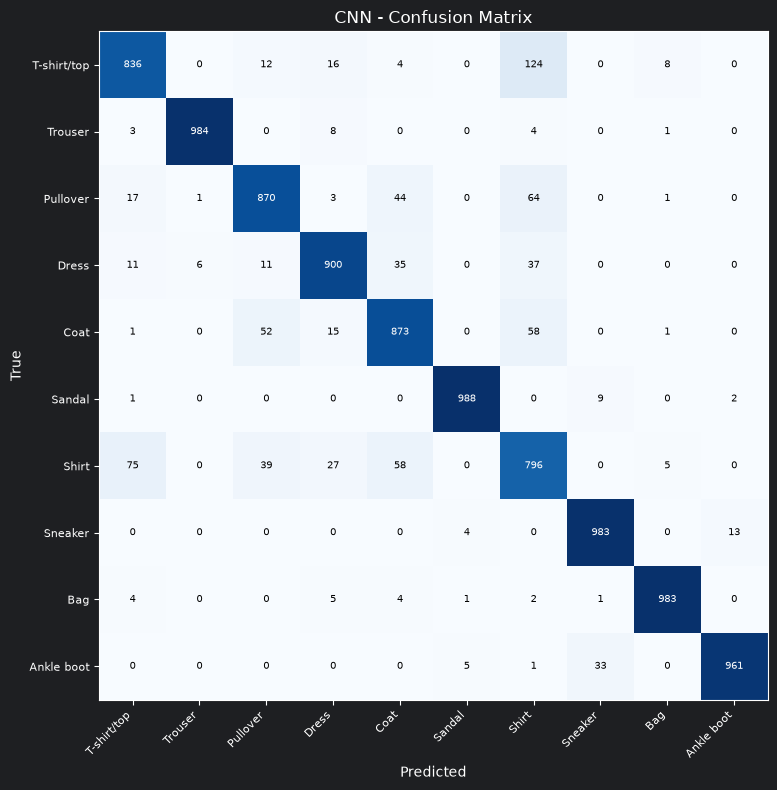

In [14]:
acc_mlp, cm_mlp, _ = evaluate_detailed(model_mlp, test_loader, device, class_names)
print('\n')
acc_cnn, cm_cnn, _ = evaluate_detailed(model_cnn, test_loader, device, class_names)

plot_confusion_matrix(cm_mlp, class_names, title='MLP - Confusion Matrix',
                      save_path='../outputs/plots/confusion_matrix_mlp.png')
plot_confusion_matrix(cm_cnn, class_names, title='CNN - Confusion Matrix',
                      save_path='../outputs/plots/confusion_matrix_cnn.png')

## 9. Compare: ROC Curves

Per-class ROC curves (10 subplots), each showing MLP vs CNN with AUC values. Macro AUC printed to console.

MLP macro ROC-AUC: 0.9903
CNN macro ROC-AUC: 0.9952


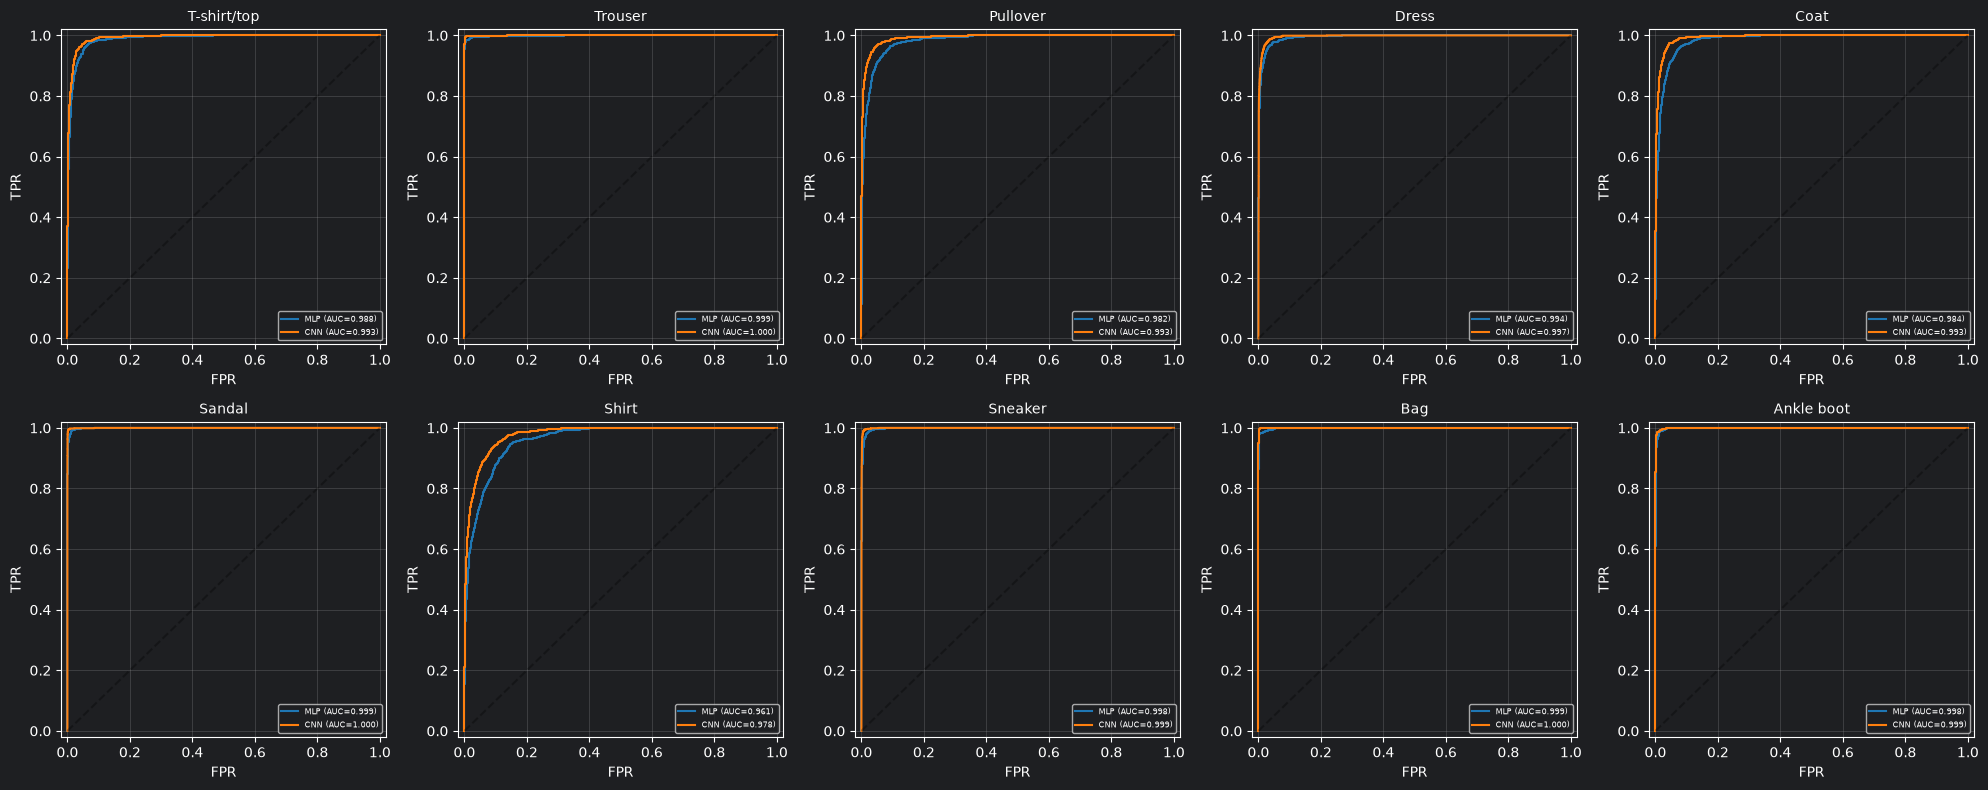

In [15]:
probas_mlp, labels = get_all_probas_and_labels(model_mlp, test_loader, device, 10)
probas_cnn, _ = get_all_probas_and_labels(model_cnn, test_loader, device, 10)

roc_mlp = compute_roc_auc_scores(probas_mlp, labels)
roc_cnn = compute_roc_auc_scores(probas_cnn, labels)

print(f'MLP macro ROC-AUC: {roc_mlp["macro"]:.4f}')
print(f'CNN macro ROC-AUC: {roc_cnn["macro"]:.4f}')

plot_roc_curves({'MLP': probas_mlp, 'CNN': probas_cnn}, labels, class_names)

## 10. Compare: PR Curves

Per-class Precision-Recall curves (10 subplots), MLP vs CNN with AP (Average Precision) values.

MLP macro PR-AUC (AP): 0.9358
CNN macro PR-AUC (AP): 0.9665


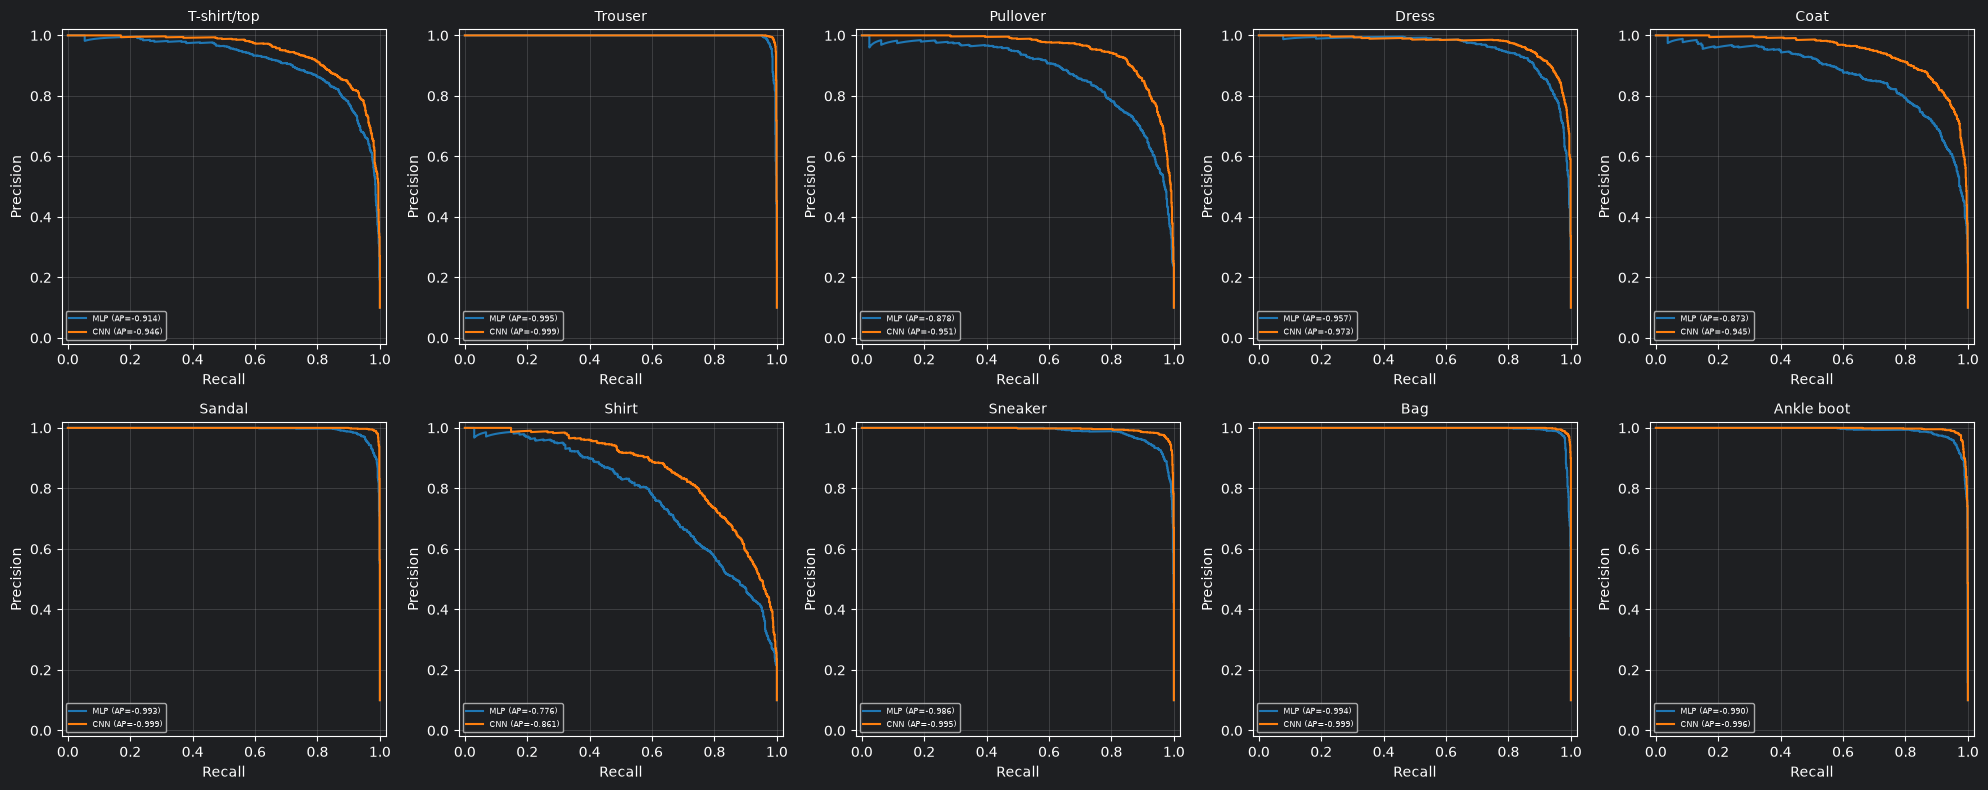

In [16]:
pr_mlp = compute_pr_auc_scores(probas_mlp, labels)
pr_cnn = compute_pr_auc_scores(probas_cnn, labels)

print(f'MLP macro PR-AUC (AP): {pr_mlp["macro"]:.4f}')
print(f'CNN macro PR-AUC (AP): {pr_cnn["macro"]:.4f}')

plot_pr_curves({'MLP': probas_mlp, 'CNN': probas_cnn}, labels, class_names)

## 11. Summary Table

Compare Accuracy, ROC-AUC, PR-AUC (macro), and parameter count side-by-side, plus per-class breakdown.

In [17]:
print_comparison_table(acc_mlp, acc_cnn, roc_mlp, roc_cnn, pr_mlp, pr_cnn,
                       mlp_params, cnn_params, class_names)

Metric                             MLP          CNN         Diff
---------------------------------------------------------------------------
Test Accuracy (%)               87.42       91.74       +4.32
Macro ROC-AUC                  0.9903      0.9952     +0.0049
Macro PR-AUC (AP)              0.9358      0.9665     +0.0307
Parameters                    235,146     421,642    +186,496

Per-class ROC-AUC                  MLP          CNN
--------------------------------------------------
T-shirt/top                    0.9882      0.9927
Trouser                        0.9991      0.9998
Pullover                       0.9821      0.9925
Dress                          0.9942      0.9969
Coat                           0.9837      0.9930
Sandal                         0.9992      0.9998
Shirt                          0.9608      0.9782
Sneaker                        0.9982      0.9995
Bag                            0.9991      0.9999
Ankle boot                     0.9984      0.9995

Per-cl

## 12. Save Models

Save `.pth` weights to `outputs/model/` for future inference without retraining.

In [18]:
save_model(model_mlp, '../outputs/model/mlp_fashion_mnist.pth')
save_model(model_cnn, '../outputs/model/cnn_fashion_mnist.pth')

Model saved to ../outputs/model/mlp_fashion_mnist.pth
Model saved to ../outputs/model/cnn_fashion_mnist.pth


## 13. Display Predicted vs Actual Images

First batch of test set: green = correct, red = wrong. MLP and CNN side-by-side.

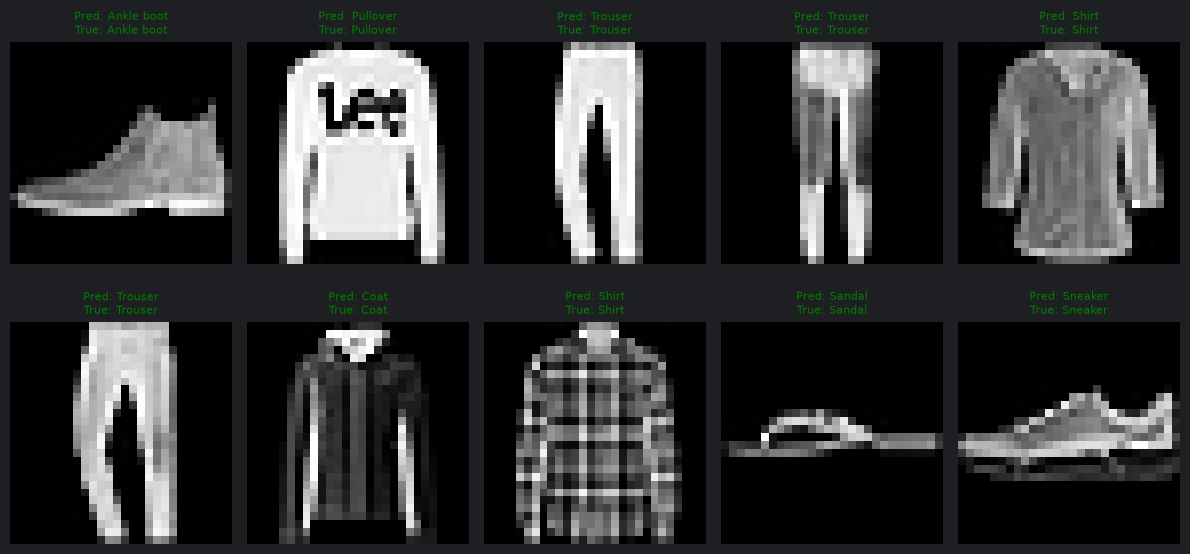

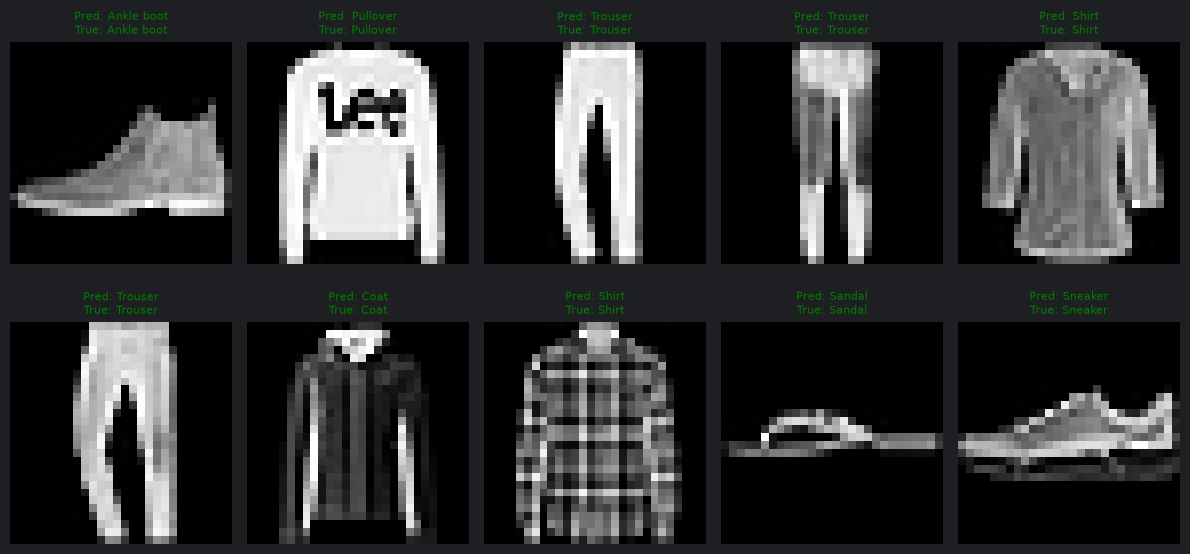

In [19]:
plot_predictions(model_mlp, test_loader, class_names, device,
               '../outputs/plots/predictions_mlp.png')
plot_predictions(model_cnn, test_loader, class_names, device,
               '../outputs/plots/predictions_cnn.png')